<a href="https://colab.research.google.com/github/Anand-Kamal/SCT_ML_2/blob/main/mall_customer_segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Customer Segmentation with K-Means Clustering

**Dataset:** Mall Customers (200 rows: `CustomerID`, `Gender`, `Age`,
`Annual Income (k$)`, `Spending Score (1-100)`)

**Goal:** Group customers into meaningful segments based on income and
spending behavior, so a business could target each group differently
(e.g. VIP marketing vs. budget promotions).

**Why this is a different kind of project from the house price model:**
there's no target column to predict here — no `SalePrice` equivalent.
This is **unsupervised learning**: the model finds structure in the data
on its own, rather than learning to reproduce a known answer.

**Method used:** K-Means clustering on `Annual Income` and `Spending
Score`, with the number of clusters (`k`) chosen using the elbow method
and silhouette score rather than guessed.

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

sns.set_style("whitegrid")
RANDOM_STATE = 42

## 0. Colab setup — upload your data

Run this cell in Colab and select `Mall_Customers.csv` when prompted.
Skip it if the file is already in your runtime.

## 1. Load the Data

In [19]:
df = pd.read_csv("Mall_Customers.csv")
print("Shape:", df.shape)
print("\nMissing values:")
print(df.isnull().sum())
df.head()

Shape: (200, 5)

Missing values:
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


## 2. Exploratory Data Analysis

In [20]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


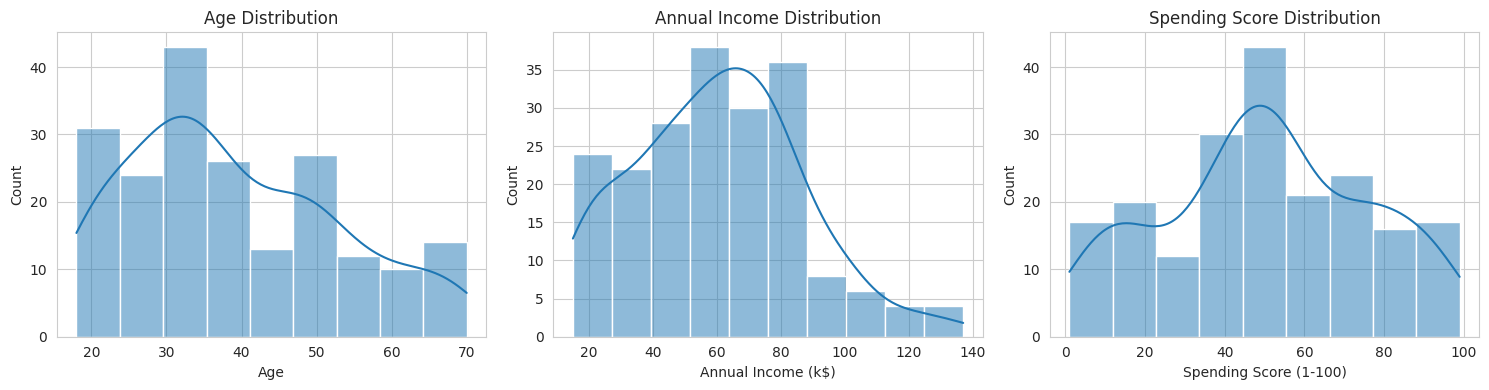

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(df["Age"], kde=True, ax=axes[0])
axes[0].set_title("Age Distribution")
sns.histplot(df["Annual Income (k$)"], kde=True, ax=axes[1])
axes[1].set_title("Annual Income Distribution")
sns.histplot(df["Spending Score (1-100)"], kde=True, ax=axes[2])
axes[2].set_title("Spending Score Distribution")
plt.tight_layout()
plt.show()

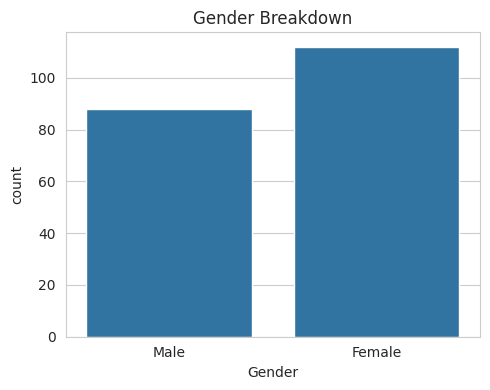

In [22]:
plt.figure(figsize=(5, 4))
sns.countplot(x="Gender", data=df)
plt.title("Gender Breakdown")
plt.tight_layout()
plt.show()

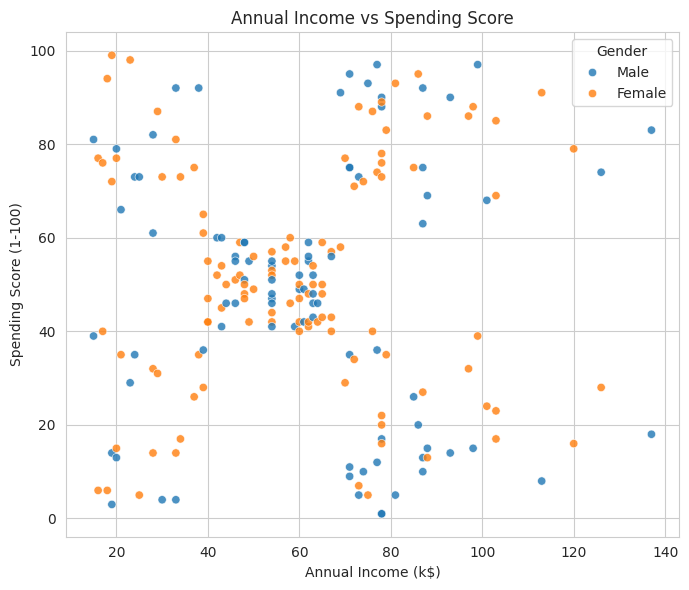

In [23]:
plt.figure(figsize=(7, 6))
sns.scatterplot(
    data=df, x="Annual Income (k$)", y="Spending Score (1-100)",
    hue="Gender", alpha=0.8
)
plt.title("Annual Income vs Spending Score")
plt.tight_layout()
plt.show()
# There's clear visual grouping here even before clustering -- a few
# obvious clumps of points, which is exactly what K-Means will formalize.

## 3. Feature Selection & Scaling

Using `Annual Income` and `Spending Score` — the two variables a business
would actually act on (who to target with which offers). K-Means uses
Euclidean distance, so features on very different scales (income in
thousands of dollars, spending score 1-100) need to be standardized first,
or income would dominate the distance calculation just because its numbers
are bigger.

In [24]:
FEATURES = ["Annual Income (k$)", "Spending Score (1-100)"]
X = df[FEATURES]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## 4. Choosing the Number of Clusters

Two standard methods, checked together rather than picking `k` by eye:
- **Elbow method** — plot inertia (within-cluster sum of squares) vs `k`;
  look for where adding another cluster stops giving a big improvement.
- **Silhouette score** — measures how well-separated clusters are
  (ranges -1 to 1, higher is better). More objective than the elbow plot
  alone, since the "elbow" can be subjective to read.

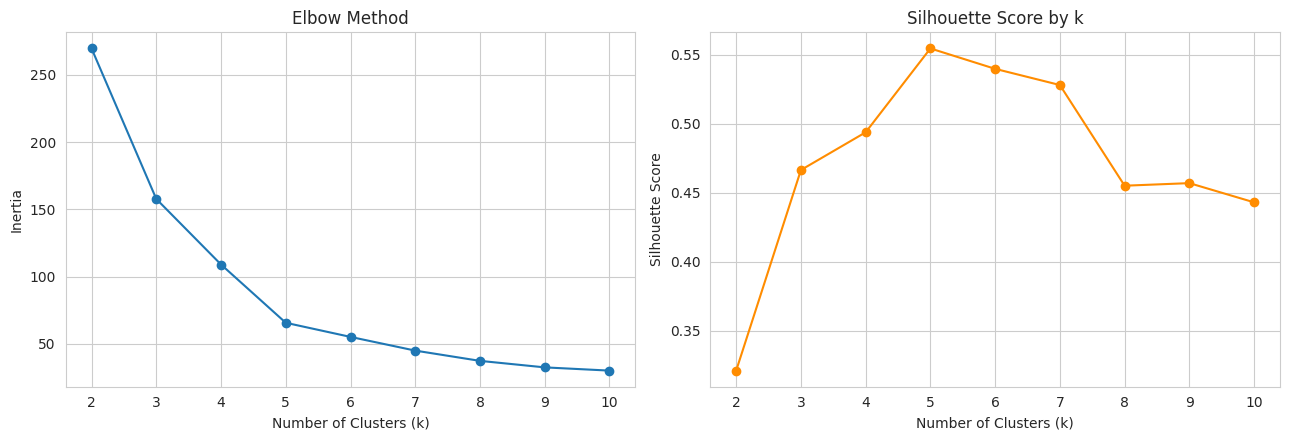

Best k by silhouette score: 5 (score = 0.5547)


In [25]:
inertias = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(list(k_range), inertias, marker="o")
axes[0].set_title("Elbow Method")
axes[0].set_xlabel("Number of Clusters (k)")
axes[0].set_ylabel("Inertia")

axes[1].plot(list(k_range), silhouette_scores, marker="o", color="darkorange")
axes[1].set_title("Silhouette Score by k")
axes[1].set_xlabel("Number of Clusters (k)")
axes[1].set_ylabel("Silhouette Score")
plt.tight_layout()
plt.show()

best_k = list(k_range)[int(np.argmax(silhouette_scores))]
print(f"Best k by silhouette score: {best_k} (score = {max(silhouette_scores):.4f})")

## 5. Fit the Final Model

`k=5` gives both the best silhouette score and a clear bend in the elbow
plot on this dataset — the two methods agree, which is a good sign it's
a genuine structural choice rather than an artifact of one metric.

In [26]:
K = 5
kmeans = KMeans(n_clusters=K, random_state=RANDOM_STATE, n_init=10)
df["Cluster"] = kmeans.fit_predict(X_scaled)

print(f"Final silhouette score (k={K}):", round(silhouette_score(X_scaled, df["Cluster"]), 4))
df["Cluster"].value_counts().sort_index()

Final silhouette score (k=5): 0.5547


,count
Cluster,
0,81
1,39
2,22
3,35
4,23


## 6. Visualize the Clusters

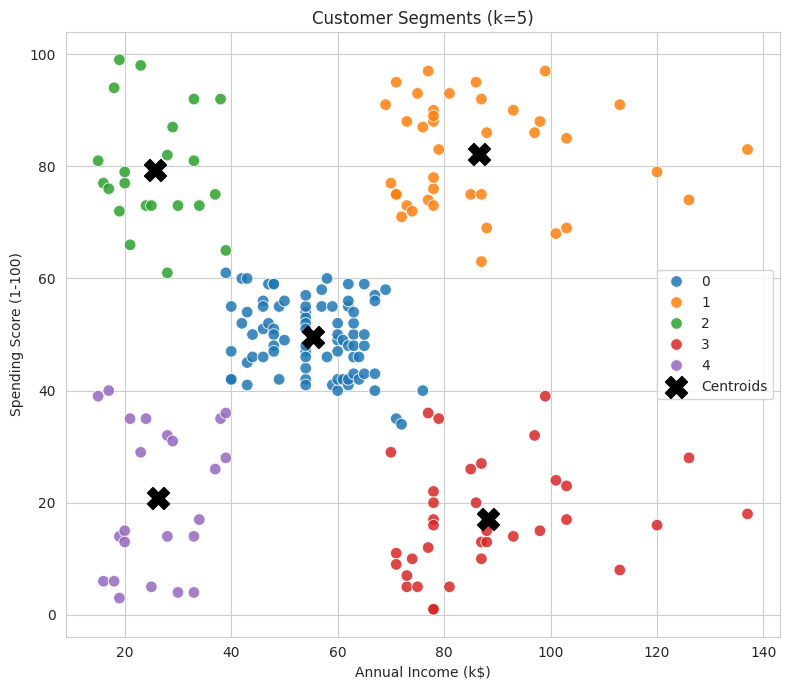

In [27]:
plt.figure(figsize=(8, 7))
palette = sns.color_palette("tab10", K)
sns.scatterplot(
    data=df, x="Annual Income (k$)", y="Spending Score (1-100)",
    hue="Cluster", palette=palette, s=70, alpha=0.85
)

# Plot centroids back in original (unscaled) units
centroids_scaled = kmeans.cluster_centers_
centroids_original = scaler.inverse_transform(centroids_scaled)
plt.scatter(
    centroids_original[:, 0], centroids_original[:, 1],
    marker="X", s=250, c="black", label="Centroids"
)

plt.title(f"Customer Segments (k={K})")
plt.legend()
plt.tight_layout()
plt.show()

## 7. Profile Each Cluster

Turning cluster numbers into descriptions a marketing team could actually
act on.

In [28]:
profile = df.groupby("Cluster").agg(
    Count=("CustomerID", "count"),
    AvgAge=("Age", "mean"),
    AvgIncome=("Annual Income (k$)", "mean"),
    AvgSpending=("Spending Score (1-100)", "mean"),
).round(1)
profile

,Count,AvgAge,AvgIncome,AvgSpending
Cluster,,,,
0,81,42.7,55.3,49.5
1,39,32.7,86.5,82.1
2,22,25.3,25.7,79.4
3,35,41.1,88.2,17.1
4,23,45.2,26.3,20.9


In [29]:
CLUSTER_LABELS = {
    0: "Standard — mid income, mid spending",
    1: "Target / VIP — high income, high spending",
    2: "Young Spenders — low income, high spending",
    3: "Careful Savers — high income, low spending",
    4: "Budget-Conscious — low income, low spending",
}

for cluster_id, label in CLUSTER_LABELS.items():
    row = profile.loc[cluster_id]
    print(f"Cluster {cluster_id} — {label}")
    print(f"  {int(row['Count'])} customers | avg age {row['AvgAge']} | "
          f"avg income ${row['AvgIncome']}k | avg spending score {row['AvgSpending']}")
    print()

Cluster 0 — Standard — mid income, mid spending
  81 customers | avg age 42.7 | avg income $55.3k | avg spending score 49.5

Cluster 1 — Target / VIP — high income, high spending
  39 customers | avg age 32.7 | avg income $86.5k | avg spending score 82.1

Cluster 2 — Young Spenders — low income, high spending
  22 customers | avg age 25.3 | avg income $25.7k | avg spending score 79.4

Cluster 3 — Careful Savers — high income, low spending
  35 customers | avg age 41.1 | avg income $88.2k | avg spending score 17.1

Cluster 4 — Budget-Conscious — low income, low spending
  23 customers | avg age 45.2 | avg income $26.3k | avg spending score 20.9



**How to read these segments:**
- **Target / VIP** (high income, high spending) — the most valuable
  segment; retention and loyalty programs matter most here.
- **Careful Savers** (high income, low spending) — has money but isn't
  spending it at the mall; the segment with the most *upside* if
  marketing can shift behavior.
- **Young Spenders** (low income, high spending) — price-sensitive but
  engaged; good fit for promotions and discounts.
- **Budget-Conscious** (low income, low spending) — lowest priority for
  most marketing spend.
- **Standard** — average on both axes; the largest, "everyone else"
  segment.

## 8. Save Labeled Data

In [30]:
df.to_csv("mall_customers_segmented.csv", index=False)
print("Saved mall_customers_segmented.csv")
df.head()

Saved mall_customers_segmented.csv


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4
